# LeetCode #752: Open the Lock

https://leetcode.com/problems/open-the-lock/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (DFS over all states)** | $O(10^4)$ | $O(10^4)$ |
| **BFS (shortest path in state graph)** | $O(10^4 + D)$ | $O(10^4 + D)$ |

---

## Understanding the Methods

### Brute Force (DFS over all states)
DFS from "0000", exploring all reachable lock combinations. Finds a path but not necessarily the shortest one — DFS goes deep before going wide, so the first path found may take many more turns than the optimal. Requires backtracking and is generally slower in practice.

### Optimal: BFS (shortest path in state graph) ★
Model the lock as a graph where each node is a 4-digit string (10^4 total states) and edges connect states reachable by one wheel turn. BFS from "0000" guarantees the first time the target is reached equals the minimum number of turns. Dead-end states (from `deadends`) are treated as walls and never enqueued.

**Why this is better than Brute Force:** BFS processes states level by level — each level is one more turn. The first path to the target is always the shortest. At most $10^4 = 10000$ states exist, giving a tight upper bound on work.

**Constraints:**
* 1 <= deadends.length <= 500
* deadends[i].length == 4, target.length == 4
* target is not "0000"
* All strings consist of digits 0-9

## Solutions

### C#

In [ ]:
public class Solution {
    public int OpenLock(string[] deadends, string target) {
        var dead = new HashSet<string>(deadends);
        if (dead.Contains("0000")) return -1;
        if (target == "0000") return 0;

        var queue = new Queue<string>();
        var visited = new HashSet<string> { "0000" };
        queue.Enqueue("0000");
        int turns = 0;

        while (queue.Count > 0) {
            turns++;
            int size = queue.Count;
            for (int i = 0; i < size; i++) {
                string cur = queue.Dequeue();
                // Try turning each of the 4 wheels up or down
                for (int w = 0; w < 4; w++) {
                    foreach (int delta in new[] { 1, -1 }) {
                        char[] next = cur.ToCharArray();
                        next[w] = (char)(((next[w] - '0' + delta + 10) % 10) + '0');
                        string nextStr = new string(next);
                        if (nextStr == target) return turns;
                        if (!visited.Contains(nextStr) && !dead.Contains(nextStr)) {
                            visited.Add(nextStr);
                            queue.Enqueue(nextStr);
                        }
                    }
                }
            }
        }
        return -1;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def openLock(self, deadends: list[str], target: str) -> int:
        dead = set(deadends)
        if "0000" in dead:
            return -1
        if target == "0000":
            return 0

        queue = deque(["0000"])
        visited = {"0000"}
        turns = 0

        while queue:
            turns += 1
            for _ in range(len(queue)):
                cur = queue.popleft()
                # Try turning each of the 4 wheels up or down
                for w in range(4):
                    for delta in (1, -1):
                        d = list(cur)
                        d[w] = str((int(d[w]) + delta) % 10)
                        nxt = "".join(d)
                        if nxt == target:
                            return turns
                        if nxt not in visited and nxt not in dead:
                            visited.add(nxt)
                            queue.append(nxt)
        return -1

### Go

In [ ]:
func openLock(deadends []string, target string) int {
    dead := make(map[string]bool)
    for _, d := range deadends {
        dead[d] = true
    }
    if dead["0000"] { return -1 }
    if target == "0000" { return 0 }

    queue := []string{"0000"}
    visited := map[string]bool{"0000": true}
    turns := 0

    for len(queue) > 0 {
        turns++
        size := len(queue)
        for i := 0; i < size; i++ {
            cur := queue[0]
            queue = queue[1:]
            b := []byte(cur)
            // Try turning each of the 4 wheels up or down
            for w := 0; w < 4; w++ {
                orig := b[w]
                for _, delta := range []int{1, -1} {
                    b[w] = byte((int(orig-'0')+delta+10)%10) + '0'
                    nxt := string(b)
                    if nxt == target { return turns }
                    if !visited[nxt] && !dead[nxt] {
                        visited[nxt] = true
                        queue = append(queue, nxt)
                    }
                }
                b[w] = orig
            }
        }
    }
    return -1
}

### Rust

In [ ]:
use std::collections::{HashSet, VecDeque};

impl Solution {
    pub fn open_lock(deadends: Vec<String>, target: String) -> i32 {
        let dead: HashSet<&str> = deadends.iter().map(|s| s.as_str()).collect();
        if dead.contains("0000") { return -1; }
        if target == "0000" { return 0; }

        let mut queue: VecDeque<Vec<u8>> = VecDeque::new();
        let mut visited: HashSet<Vec<u8>> = HashSet::new();
        let start = b"0000".to_vec();
        queue.push_back(start.clone());
        visited.insert(start);
        let target_bytes = target.as_bytes().to_vec();
        let mut turns = 0;

        while !queue.is_empty() {
            turns += 1;
            let size = queue.len();
            for _ in 0..size {
                let cur = queue.pop_front().unwrap();
                // Try turning each of the 4 wheels up or down
                for w in 0..4 {
                    for delta in [1i32, -1] {
                        let mut nxt = cur.clone();
                        nxt[w] = b'0' + ((nxt[w] as i32 - b'0' as i32 + delta + 10) % 10) as u8;
                        if nxt == target_bytes { return turns; }
                        let s: String = String::from_utf8(nxt.clone()).unwrap();
                        if !visited.contains(&nxt) && !dead.contains(s.as_str()) {
                            visited.insert(nxt.clone());
                            queue.push_back(nxt);
                        }
                    }
                }
            }
        }
        -1
    }
}

## Example Scenarios

**1. Common Case**
**Input:** deadends=["0201","0101","0102","1212","2002"], target="0202"
BFS from "0000": turn 1 → try {"1000","9000","0100","0900","0010","0090","0001","0009"}. "0100" is a deadend — skip. Turn 2 → from "0001": "0002" valid → enqueue. Continue expanding until "0202" is reached. Result: 6 turns.

**2. Slightly Complex**
**Input:** deadends=["8888"], target="0009"
Only "8888" is blocked; "0009" is one turn from "0000" (wheel 3 down: 0→9). BFS finds it at turn 1. Demonstrates that a single deadend far from the path has no effect on a nearby target.

**3. Edge Case: Time Factor**
**Input:** deadends=[] (no deadends), target="9999"
The state graph has 10^4 = 10000 nodes. BFS explores states in order of turns. "9999" requires 4 turns (each wheel from 0 to 9 takes min(9,1)=1 turn, so all 4 wheels = 4). BFS reaches it at turn 4 after exploring all states within 3 turns. Maximum BFS levels explored without deadends. Total operations: $O(10^4)$.

**4. Edge Case: Space Factor**
**Input:** deadends covers 499 specific 4-digit strings, target="9999" blocked by deadends around it.
Visited set grows to cover all reachable states — up to 10000 − 500 = 9500 strings. Each string is 4 chars. Total visited set memory: $9500 \times 4 = 38000$ bytes — still $O(10^4)$. The dead set holds 500 strings. Combined space: $O(10^4 + D)$ where $D = |\text{deadends}|$.

**5. Almost-Impossible but Plausible**
**Input:** deadends=["0000"]
The start state itself is a deadend. The guard `dead.Contains("0000") → return -1` fires immediately before any BFS. Without this guard, "0000" would be enqueued, dequeued, and all 8 neighbours explored — but since visited already marks "0000", the BFS would still terminate correctly. The guard is nonetheless critical: without it on some implementations, returning -1 for an unreachable target would require fully exhausting the queue.

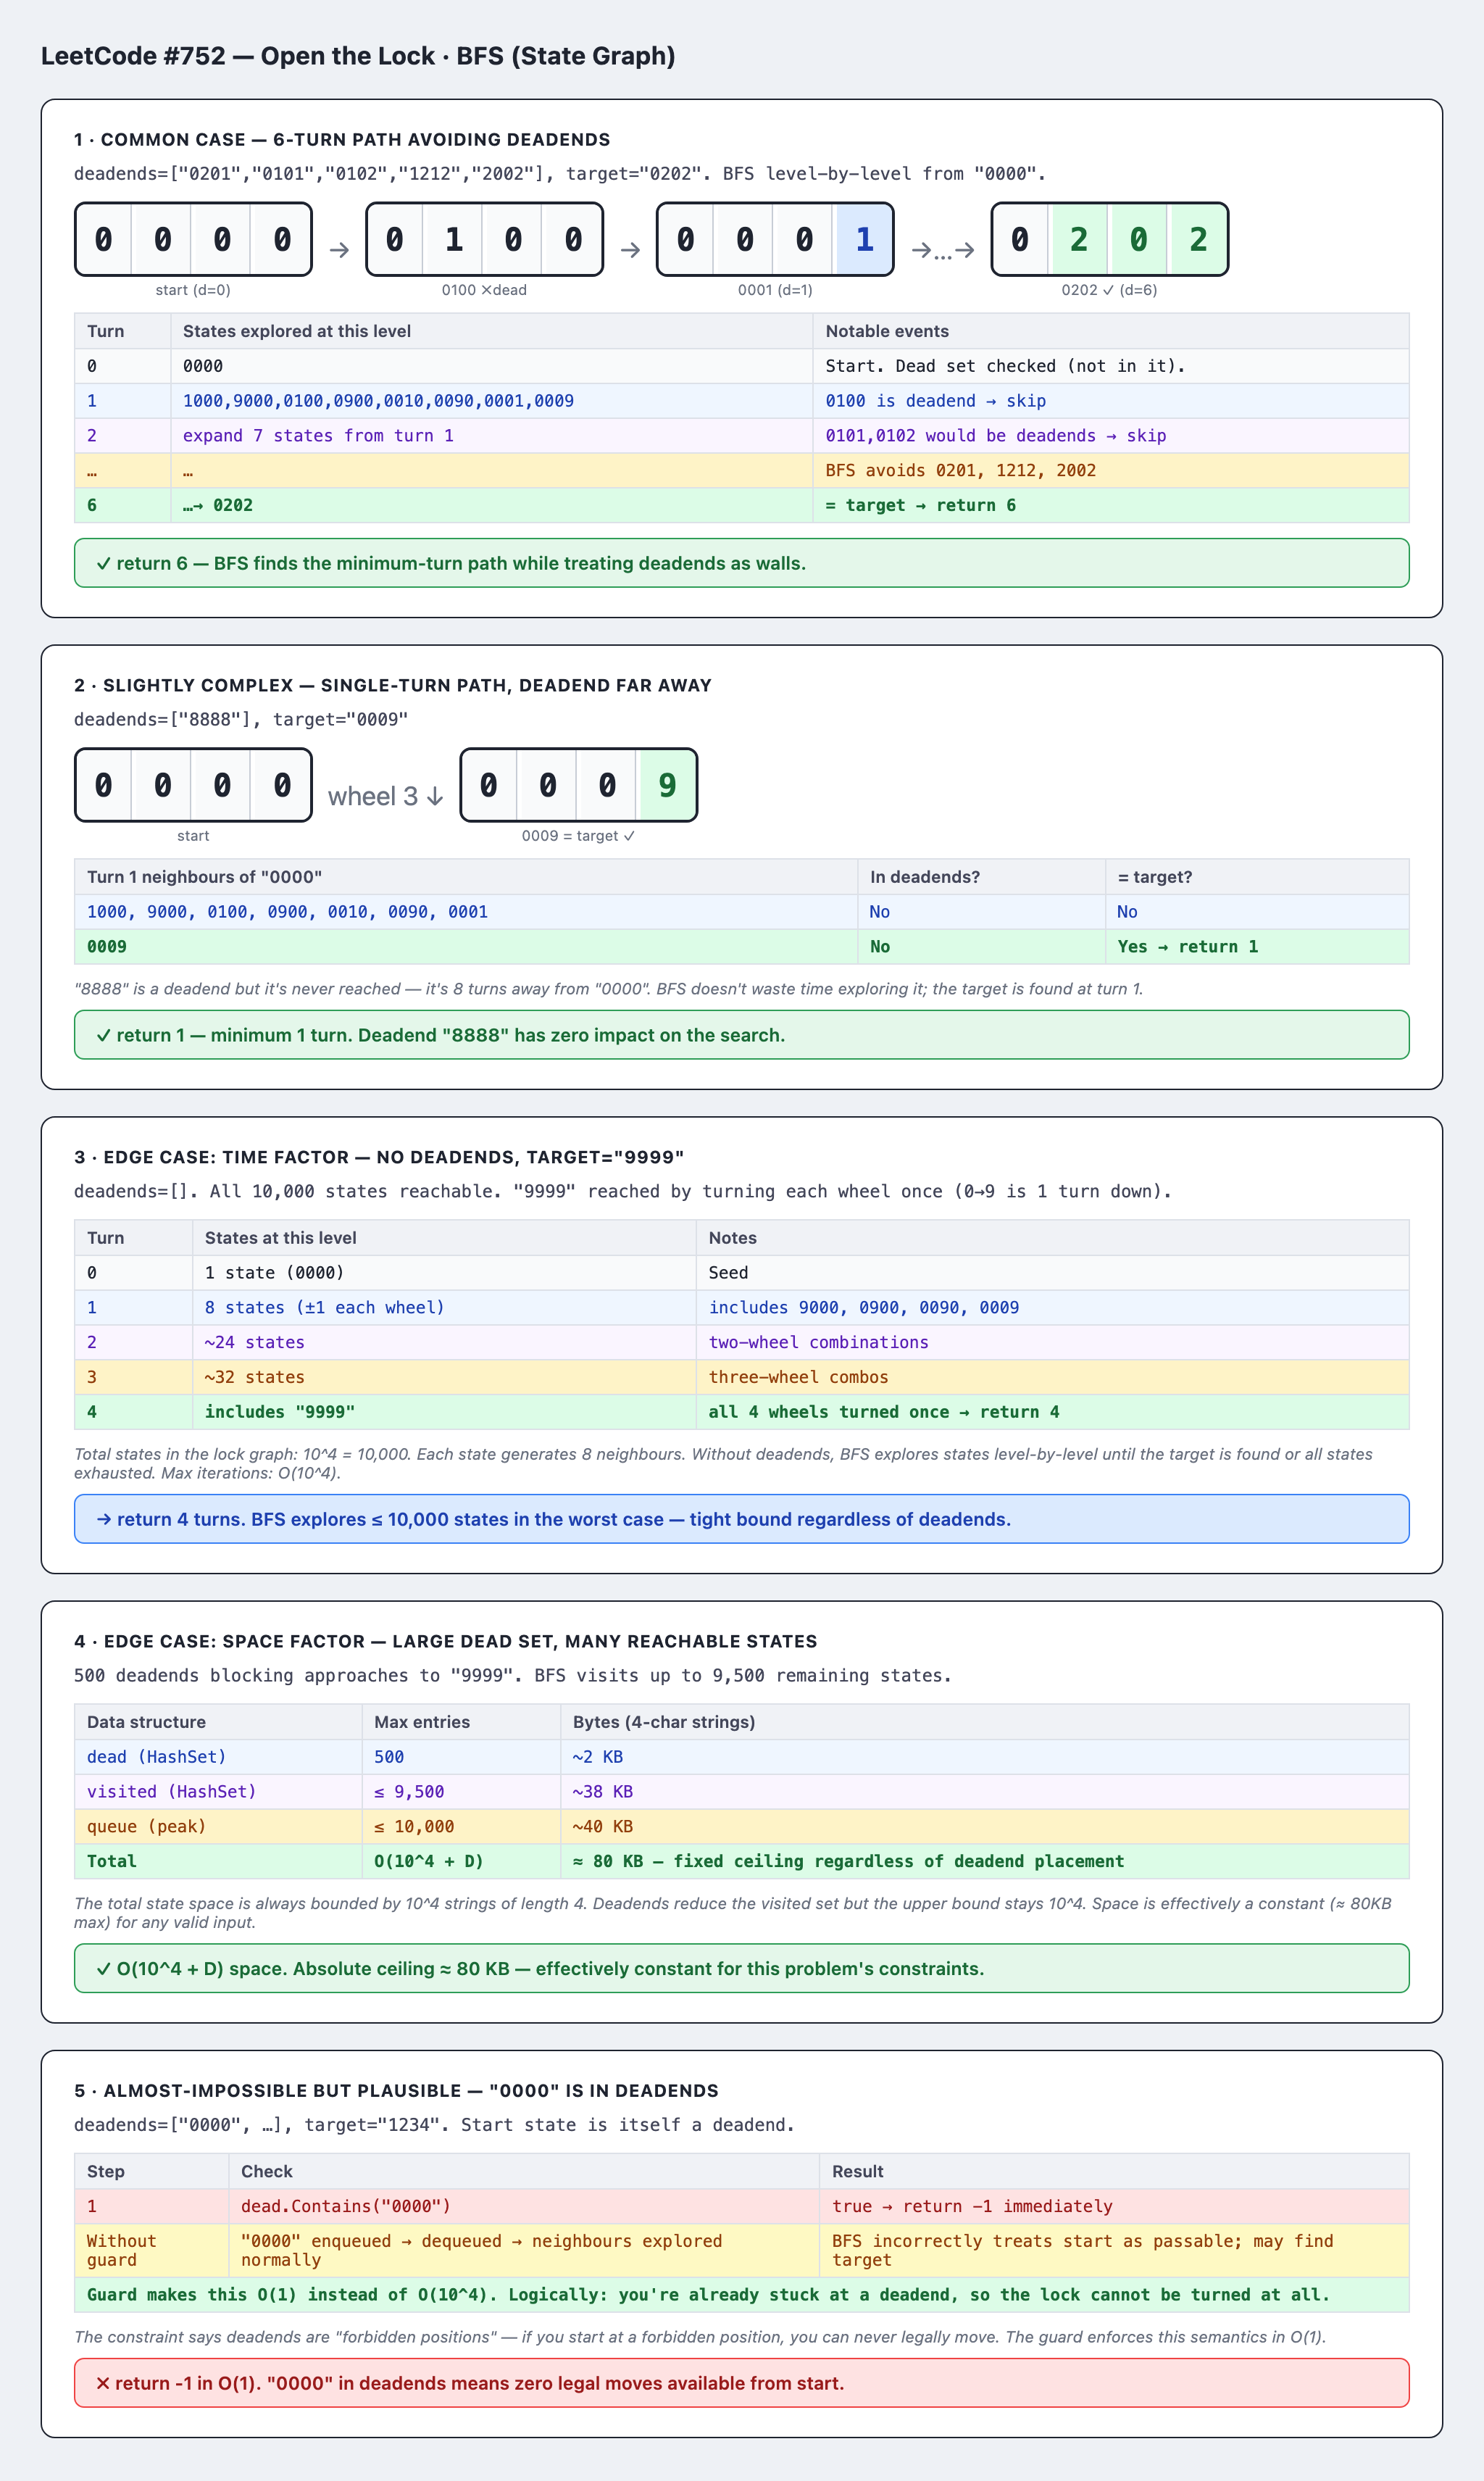